## Initialize

In [1]:
import pyscf
import numpy as np
from pyscf.fci import cistring


mol = pyscf.M(
    atom = 'O 0 0 0; O 0 0 1.1',  
    basis = 'sto-3g',
    symmetry = True,
    spin = 2,
    
)
myhf = mol.RHF().run()

# #
# # create an FCI solver based on the SCF object
# #
cisolver = pyscf.fci.FCI(myhf)
cie,civ=cisolver.kernel()
print(civ )
num_orbitals = myhf.mo_coeff.shape[1]
print(num_orbitals)
num_alpha_electrons, num_beta_electrons = mol.nelec
print(num_alpha_electrons,num_beta_electrons)
print(civ.shape)

# #
# # create an FCI solver based on the SCF object
# #


alpha_state=np.concatenate((np.ones(num_alpha_electrons),np.zeros(num_orbitals-num_alpha_electrons)),
                           axis=0)
beta_state=np.concatenate((np.ones(num_beta_electrons),np.zeros(num_orbitals-num_beta_electrons)),
                           axis=0)
print(alpha_state,beta_state)

stra=cistring.addr2str(10,7,10)
print(bin(stra))

converged SCF energy = -147.590894030918
[[-9.19854131e-02  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 ...
 [ 0.00000000e+00  0.00000000e+00 -4.92786279e-02 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00 -2.20629094e-04 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 3.48841749e-05  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]]
10
9 7
(10, 120)
[1. 1. 1. 1. 1. 1. 1. 1. 1. 0.] [1. 1. 1. 1. 1. 1. 1. 0. 0. 0.]
0b101101111


/opt/homebrew/lib/python3.10/site-packages/numpy/linalg/linalg.py:2180: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/opt/homebrew/lib/python3.10/site-packages/numpy/linalg/linalg.py:2180: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)


## MLP NN

In [2]:
from tcnqs import mlp
from tcnqs.utils import generate_ci_data
from jax import random
import matplotlib.pyplot as plt


rng = random.PRNGKey(7)

x_train, y_train = generate_ci_data(num_orbitals,num_alpha_electrons,num_beta_electrons,civ)
input_size = 2*num_orbitals # Example input size
num_samples = len(y_train) # Number of training samples

model_mlp, variables_mlp = mlp.create_model(rng, (input_size,))
state_MLP = mlp.create_train_state(rng, model_mlp, variables_mlp)

# Training loop
num_epochs = 50
batch_size = 1
train_losses_MLP = []

for epoch in range(num_epochs):
    epoch_loss = 0.0
    for i in range(0, num_samples, batch_size):
        batch = (x_train[i:i+batch_size], y_train[i:i+batch_size])
        state_MLP, loss = mlp.train_step(state_MLP, batch)
        epoch_loss += loss
    
    average_epoch_loss = epoch_loss / (num_samples // batch_size)
    train_losses_MLP.append(average_epoch_loss)
    print(f"Epoch {epoch+1}, Loss: {average_epoch_loss}")

(1,)
(1, 1)
(1, 1)
Epoch 1, Loss: 0.007406697142869234
Epoch 2, Loss: 0.003552634734660387
Epoch 3, Loss: 0.0021250545978546143
Epoch 4, Loss: 0.0016198188532143831
Epoch 5, Loss: 0.0013085235841572285
Epoch 6, Loss: 0.001150605734437704
Epoch 7, Loss: 0.001057230168953538
Epoch 8, Loss: 0.00100085383746773
Epoch 9, Loss: 0.0009493179386481643
Epoch 10, Loss: 0.0009217502665705979
Epoch 11, Loss: 0.0008831020095385611
Epoch 12, Loss: 0.0008384765242226422
Epoch 13, Loss: 0.0008103061700239778
Epoch 14, Loss: 0.0007838653982616961
Epoch 15, Loss: 0.0007650182233192027
Epoch 16, Loss: 0.0007325964979827404
Epoch 17, Loss: 0.000705864280462265
Epoch 18, Loss: 0.0006728015141561627
Epoch 19, Loss: 0.0006335077341645956
Epoch 20, Loss: 0.000589956936892122
Epoch 21, Loss: 0.0005399156361818314
Epoch 22, Loss: 0.000488799239974469
Epoch 23, Loss: 0.000441024691099301
Epoch 24, Loss: 0.00039355288026854396
Epoch 25, Loss: 0.0003561825433280319
Epoch 26, Loss: 0.0003175838792230934
Epoch 27, L

## Back Flow CODE 2
- 1 Error Grads are 0 (Machine Not Learning)
- 2 Issue Jit(grad) not working (slow compilation)

In [4]:
from jax.nn.initializers import normal 
from jax import random
from tcnqs import backflow as bf

# Main function

rng = random.PRNGKey(7)

x_train, y_train = generate_ci_data(num_orbitals,num_alpha_electrons,num_beta_electrons,civ)
input_size = 2*num_orbitals 
num_samples = len(y_train) 

model, variables = bf.create_model(rng, input_size,
                                num_electrons=num_alpha_electrons+num_beta_electrons)
state = bf.create_train_state(rng, model, variables)
#print(variables)
# Training loop
num_epochs = 50
batch_size = 1
train_losses = []

for epoch in range(num_epochs):
    epoch_loss = 0.0
    for i in range(0, num_samples, batch_size):
        batch = (x_train[i:i+batch_size], y_train[i:i+batch_size])
        state, loss = bf.train_step(state, batch)
        epoch_loss += loss
    
    average_epoch_loss = epoch_loss / (num_samples // batch_size)
    train_losses.append(average_epoch_loss)
    print(f"Epoch {epoch+1}, Loss: {average_epoch_loss}")

# Plotting the training curve

Traced<ShapedArray(int32[16])>with<DynamicJaxprTrace(level=1/0)>


Epoch 1, Loss: 2149.99658203125
Epoch 2, Loss: 47.912532806396484
Epoch 3, Loss: 9.142678260803223
Epoch 4, Loss: 1.9134267568588257
Epoch 5, Loss: 0.9044914841651917
Epoch 6, Loss: 0.5469215512275696
Epoch 7, Loss: 0.30718618631362915
Epoch 8, Loss: 0.302774041891098
Epoch 9, Loss: 0.28252506256103516
Epoch 10, Loss: 0.13701185584068298
Epoch 11, Loss: 0.07907038927078247
Epoch 12, Loss: 0.11484725773334503
Epoch 13, Loss: 195750752.0
Epoch 14, Loss: 9465922.0
Epoch 15, Loss: 1814990.25
Epoch 16, Loss: 967882.875
Epoch 17, Loss: 532486.625
Epoch 18, Loss: 274244.4375
Epoch 19, Loss: 140653.578125
Epoch 20, Loss: 71889.8828125
Epoch 21, Loss: 36903.81640625
Epoch 22, Loss: 18788.583984375
Epoch 23, Loss: 10332.6103515625
Epoch 24, Loss: 5331.3515625
Epoch 25, Loss: 2715.3984375
Epoch 26, Loss: 1366.0882568359375
Epoch 27, Loss: 824.4380493164062
Epoch 28, Loss: 621.9253540039062
Epoch 29, Loss: 535.7681884765625
Epoch 30, Loss: 467.11541748046875
Epoch 31, Loss: 95.1946792602539
Epoch 

##### Identification of error
- grad for jax.linalg.det is 0
- not a problem with determinant check other stuff


### Backflow vs MLP

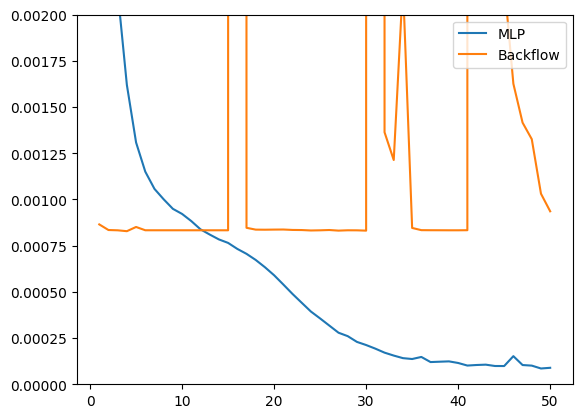

In [18]:
# Plotting the training curve
plt.plot(range(1, num_epochs + 1), train_losses_MLP, label="MLP")
plt.plot(range(1, num_epochs + 1), train_losses, label="Backflow")
plt.legend(loc="upper right")
plt.ylim(0,0.002)
plt.show()



In [121]:
a = 8  # In binary: 0101
b = 3  # In binary: 0011

result = a | b  # Result in binary: 0111, which is 7 in decimal
print(result,bin(a),bin(b),bin(result))  # Output: 7


11 0b1000 0b11 0b1011


In [16]:
def single_fermionic_excitations(occupancy_string):
    excitations = []
    n = len(occupancy_string)
    
    # Convert string to list for mutability
    occupancy_list = list(occupancy_string)
    
    for i in range(n):
        if occupancy_list[i] == '1':
            for j in range(n):
                if occupancy_list[j] == '0':
                    # Create a copy of the list
                    new_state = occupancy_list[:]
                
                    # Perform the excitation
                    new_state[i] = '0'
                    new_state[j] = '1'
                    # Convert back to string and add to excitations list
                    excitations.append(''.join(new_state))
    
    return excitations

occupancy_string = '101000'
excitations = single_fermionic_excitations(occupancy_string)

print(excitations)


['011000', '001100', '001010', '001001', '110000', '100100', '100010', '100001']


In [15]:
from itertools import combinations


def double_fermionic_excitations(occupancy_string):
    excitations = []
    n = len(occupancy_string)
    
    
    occupancy_list = list(occupancy_string)
    
    occupied_positions = [i for i, bit in enumerate(occupancy_list) if bit == '1']
    hole_positions = [i for i, bit in enumerate(occupancy_list) if bit == '0']
    
    
    for occupied_pair in combinations(occupied_positions, 2):
        for hole_pair in combinations(hole_positions, 2):
            
            new_state = occupancy_list[:]
            
            
            new_state[occupied_pair[0]] = '0'
            new_state[occupied_pair[1]] = '0'
            new_state[hole_pair[0]] = '1'
            new_state[hole_pair[1]] = '1'
            
            
            excitations.append(''.join(new_state))
    
    return excitations


occupancy_string = '101000'
excitations = double_fermionic_excitations(occupancy_string)

print(excitations)


['010100', '010010', '010001', '000110', '000101', '000011']


In [22]:
a='010100'
b='0b010011'
c= bin("0b"+a)|bin("0b"+b)
print(c)
print(bin(5))

TypeError: 'str' object cannot be interpreted as an integer

0b101
